# Combined Screening Example — Residue Contacts + Surface Overlap + Water Displacement

End-to-end demonstration of scoring docked poses using:

1. **Residue contact scoring** — Tversky, Jaccard, coverage metrics
2. **Surface overlap scoring** — fraction of pocket vertices covered by ligand atoms
3. **Water displacement scoring** — count of displaced unhappy/very-unhappy water sites (WaterFLAP & WaterMap)
4. **Combined scoring** — weighted combination selecting the best pose across all pockets

**Inputs (DRD5 example):**
- `pocket_residue_contacts_ang_3.csv` — residue contacts per pocket
- `pockets.npz` — pocket surface vertices
- `annotated_interactions.csv` — annotated ligand–residue interactions
- `glide_real_sdf_1.sdf` — docked ligand poses (standardised SDF)
- `WFapo_8IRV.pdb` — WaterFLAP hydration sites
- `8irv_wm_data.csv` + `8irv_wm_waters.pdb` — WaterMap hydration sites

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from rdkit import Chem

from pocket_ligand_screener.screener import (
    ResidueContactScorer,
    SurfaceOverlapScorer,
    WaterDisplacementScorer,
    annotate_all_pockets,
    coords_from_mol,
    score_all_poses,
    select_best_pose,
)
from water_annotator import WaterFLAPAnnotator, WaterMapAnnotator

## 1. Load data

Load pocket definitions (residue contacts + surface vertices), annotated interactions, and docked poses.

In [ ]:
DATA_DIR = Path("../tests/test_data/drd5_example")

# Pocket residue contacts
pocket_csv_path = DATA_DIR / "pocket_residue_contacts_ang_3.csv"
pocket_df = pd.read_csv(pocket_csv_path)
print(f"Pocket CSV: {pocket_df.shape[0]} rows")
print(f"Pockets: {pocket_df['pocket'].unique().tolist()}")

# Annotated interactions
interactions_csv = DATA_DIR / "annotated_interactions.csv"
interactions_df = pd.read_csv(interactions_csv)
print(f"\nInteractions: {interactions_df.shape[0]} rows")
print(f"Poses: {sorted(interactions_df['docked_ligand_index'].unique())}")

# Docked poses SDF
sdf_path = Path("../tests/test_data/glide_real_sdf_1.sdf")
supplier = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
mols = [m for m in supplier if m is not None]
print(f"\nSDF: {len(mols)} mol objects loaded")

# Pocket surface vertices
npz_path = DATA_DIR / "pockets.npz"

# WaterFLAP hydration sites
waterflap_pdb = DATA_DIR / "WFapo_8IRV.pdb"
wf_annotator = WaterFLAPAnnotator(pdb_path=waterflap_pdb)
wf_annotator.annotate(DATA_DIR / "waterflap_annotated.pdb", title="DRD5 WaterFLAP")
print(f"\nWaterFLAP: {len(wf_annotator)} water sites loaded")

# WaterMap hydration sites
wm_csv = DATA_DIR / "8irv_wm_data.csv"
wm_pdb = DATA_DIR / "8irv_wm_waters.pdb"
wm_annotator = WaterMapAnnotator(csv_path=wm_csv, water_pdb_path=wm_pdb)
wm_annotator.annotate(DATA_DIR / "watermap_annotated.pdb", title="DRD5 WaterMap")
print(f"WaterMap:  {len(wm_annotator)} water sites loaded")

Pocket CSV: 67 rows
Pockets: ['C1=_pocket_1', 'C1=_pocket_2', 'C1=_pocket_3']

Interactions: 1531 rows
Poses: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

SDF: 24 mol objects loaded


## 2. Residue contact scoring

Create a `ResidueContactScorer` per pocket and compare the four scoring metrics:
**count**, **coverage**, **Jaccard**, **Tversky**.

In [13]:
pocket_names = pocket_df["pocket"].unique().tolist()

# Build a scorer per pocket
residue_scorers = {
    name: ResidueContactScorer(pocket_csv_path, pocket_name=name)
    for name in pocket_names
}

# Show pocket residue counts
for name, scorer in residue_scorers.items():
    print(f"{name}: {len(scorer.pocket_residues)} residues")

C1=_pocket_1: 15 residues
C1=_pocket_2: 9 residues
C1=_pocket_3: 6 residues


In [15]:
# Score all poses against all pockets using residue metrics only
residue_rows = []
for pose_idx, pose_df in interactions_df.groupby("docked_ligand_index"):
    for pocket_name, scorer in residue_scorers.items():
        scores = scorer.score_all(pose_df, alpha=1.0, beta=0.3)
        scores["docked_ligand_index"] = pose_idx
        scores["pocket_name"] = pocket_name
        residue_rows.append(scores)

residue_scores_df = pd.DataFrame(residue_rows)
residue_scores_df = residue_scores_df[
    ["docked_ligand_index", "pocket_name", "count", "coverage", "jaccard", "tversky"]
]

print(f"Score matrix: {residue_scores_df.shape[0]} rows "
      f"({interactions_df['docked_ligand_index'].nunique()} poses × {len(pocket_names)} pockets)")
residue_scores_df.sort_values(["pocket_name", "tversky"], ascending=[True, False]).head(12)

Score matrix: 72 rows (24 poses × 3 pockets)


,docked_ligand_index,pocket_name,count,coverage,jaccard,tversky
51,17,C1=_pocket_1,14.0,0.933333,0.823529,0.897436
36,12,C1=_pocket_1,13.0,0.866667,0.722222,0.817610
0,0,C1=_pocket_1,12.0,0.800000,0.666667,0.754717
15,5,C1=_pocket_1,12.0,0.800000,0.666667,0.754717
63,21,C1=_pocket_1,12.0,0.800000,0.666667,0.754717
45,15,C1=_pocket_1,11.0,0.733333,0.647059,0.705128
48,16,C1=_pocket_1,11.0,0.733333,0.611111,0.691824
18,6,C1=_pocket_1,11.0,0.733333,0.578947,0.679012
12,4,C1=_pocket_1,10.0,0.666667,0.526316,0.617284
21,7,C1=_pocket_1,9.0,0.600000,0.500000,0.566038


### Heatmap — Tversky scores per pose × pocket

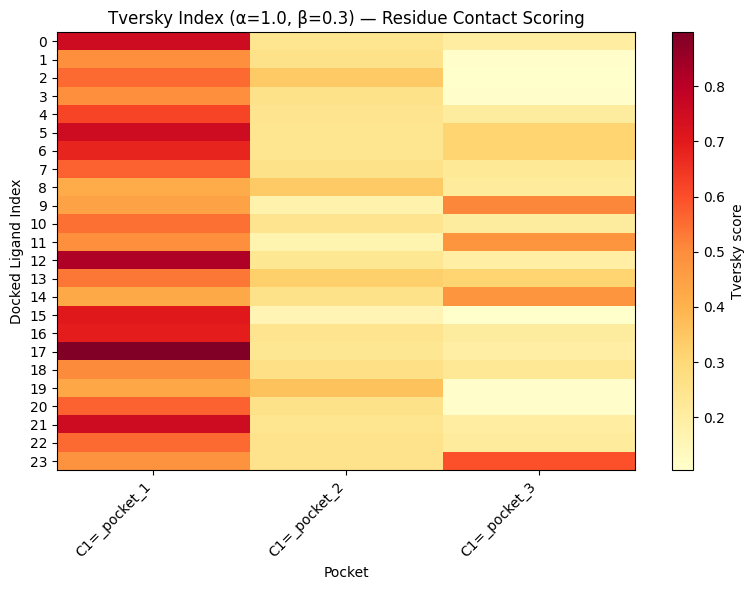

In [16]:
import matplotlib.pyplot as plt

pivot = residue_scores_df.pivot(
    index="docked_ligand_index", columns="pocket_name", values="tversky"
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Pocket")
ax.set_ylabel("Docked Ligand Index")
ax.set_title("Tversky Index (α=1.0, β=0.3) — Residue Contact Scoring")
fig.colorbar(im, ax=ax, label="Tversky score")
plt.tight_layout()
plt.show()

## 3. Surface overlap scoring

Create a `SurfaceOverlapScorer` from `pockets.npz` and score each pose by the fraction of pocket vertices covered by ligand atoms (within 2.5 Å cutoff).

In [18]:
surface_scorer = SurfaceOverlapScorer(npz_path, distance_cutoff=2.5)

for name, vertices in surface_scorer.pockets.items():
    print(f"{name}: {vertices.shape[0]} vertices")

C1=_pocket_1: 188 vertices
C1=_pocket_2: 152 vertices
C1=_pocket_3: 54 vertices


In [19]:
# Score each pose against each pocket
surface_rows = []
for i, mol in enumerate(mols):
    coords = coords_from_mol(mol)
    pocket_scores = surface_scorer.score_all_pockets(coords)
    for pocket_name, cov in pocket_scores.items():
        surface_rows.append({
            "docked_ligand_index": i,
            "pocket_name": pocket_name,
            "surface_coverage": cov,
            "vertices_covered": surface_scorer.score_count(coords, pocket_name=pocket_name),
        })

surface_scores_df = pd.DataFrame(surface_rows)
print(f"Score matrix: {surface_scores_df.shape[0]} rows")
surface_scores_df.sort_values(["pocket_name", "surface_coverage"], ascending=[True, False]).head(12)

Score matrix: 72 rows


,docked_ligand_index,pocket_name,surface_coverage,vertices_covered
0,0,C1=_pocket_1,1.0,188
6,2,C1=_pocket_1,1.0,188
12,4,C1=_pocket_1,1.0,188
15,5,C1=_pocket_1,1.0,188
21,7,C1=_pocket_1,1.0,188
27,9,C1=_pocket_1,1.0,188
30,10,C1=_pocket_1,1.0,188
36,12,C1=_pocket_1,1.0,188
45,15,C1=_pocket_1,1.0,188
48,16,C1=_pocket_1,1.0,188


### Heatmap — Surface coverage per pose × pocket

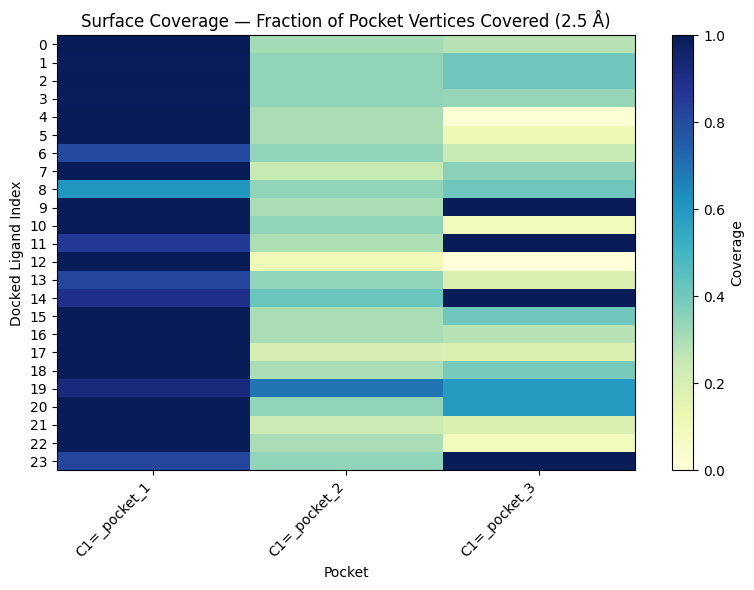

In [20]:
pivot_surf = surface_scores_df.pivot(
    index="docked_ligand_index", columns="pocket_name", values="surface_coverage"
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot_surf.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(pivot_surf.columns)))
ax.set_xticklabels(pivot_surf.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_surf.index)))
ax.set_yticklabels(pivot_surf.index)
ax.set_xlabel("Pocket")
ax.set_ylabel("Docked Ligand Index")
ax.set_title("Surface Coverage — Fraction of Pocket Vertices Covered (2.5 Å)")
fig.colorbar(im, ax=ax, label="Coverage")
plt.tight_layout()
plt.show()

## 4. Water displacement scoring

Create a `WaterDisplacementScorer` from each annotator's sites and score every pose by the number of displaced unhappy/very-unhappy water sites (within 2.0 Å cutoff). Compare WaterFLAP vs WaterMap side by side.

In [ ]:
# WaterFLAP scorer
wf_water_scorer = WaterDisplacementScorer(wf_annotator.sites, displacement_cutoff=2.0)
print(f"WaterFLAP — target waters: {wf_water_scorer.n_target_waters} / {len(wf_annotator)} total")

# WaterMap scorer
wm_water_scorer = WaterDisplacementScorer(wm_annotator.sites, displacement_cutoff=2.0)
print(f"WaterMap  — target waters: {wm_water_scorer.n_target_waters} / {len(wm_annotator)} total")

# Score each pose with both
water_rows = []
for i, mol in enumerate(mols):
    coords = coords_from_mol(mol)
    water_rows.append({
        "docked_ligand_index": i,
        "wf_displaced": wf_water_scorer.score(coords),
        "wm_displaced": wm_water_scorer.score(coords),
    })

water_scores_df = pd.DataFrame(water_rows)
print(f"\nDisplaced water counts per pose:")
water_scores_df.sort_values("wf_displaced", ascending=False).head(12)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
x = water_scores_df["docked_ligand_index"]

axes[0].bar(x, water_scores_df["wf_displaced"], color="indianred")
axes[0].set_xlabel("Docked Ligand Index")
axes[0].set_ylabel("Displaced Unhappy Waters")
axes[0].set_title(f"WaterFLAP ({wf_water_scorer.n_target_waters} targets)")
axes[0].set_xticks(x)

axes[1].bar(x, water_scores_df["wm_displaced"], color="steelblue")
axes[1].set_xlabel("Docked Ligand Index")
axes[1].set_title(f"WaterMap ({wm_water_scorer.n_target_waters} targets)")
axes[1].set_xticks(x)

plt.suptitle("Water Displacement Score per Pose (cutoff = 2.0 Å)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Combined scoring

Use `score_all_poses` to compute residue, surface, and water displacement metrics together, then `select_best_pose` to pick the winning pose. We run the combined scoring with both WaterFLAP and WaterMap water scorers and compare the selected best pose.

In [ ]:
score_kwargs = dict(
    interactions_df=interactions_df,
    residue_scorers=residue_scorers,
    surface_scorer=surface_scorer,
    alpha=1.0,
    beta=0.3,
    residue_weight=0.5,
    surface_weight=0.3,
    water_weight=0.2,
)

# --- WaterFLAP ---
supplier_wf = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
wf_combined_df = score_all_poses(**score_kwargs, sdf_supplier=supplier_wf, water_scorer=wf_water_scorer)

# --- WaterMap ---
supplier_wm = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
wm_combined_df = score_all_poses(**score_kwargs, sdf_supplier=supplier_wm, water_scorer=wm_water_scorer)

print("WaterFLAP combined scores:")
wf_combined_df.sort_values("combined_score", ascending=False).head(6)

Combined scores: (72, 8)


,docked_ligand_index,pocket_name,residue_count,residue_coverage,residue_jaccard,residue_tversky,surface_coverage,combined_score
51,17,C1=_pocket_1,14.0,0.933333,0.823529,0.897436,1.0,0.938462
36,12,C1=_pocket_1,13.0,0.866667,0.722222,0.817610,1.0,0.890566
15,5,C1=_pocket_1,12.0,0.800000,0.666667,0.754717,1.0,0.852830
63,21,C1=_pocket_1,12.0,0.800000,0.666667,0.754717,1.0,0.852830
0,0,C1=_pocket_1,12.0,0.800000,0.666667,0.754717,1.0,0.852830
45,15,C1=_pocket_1,11.0,0.733333,0.647059,0.705128,1.0,0.823077
48,16,C1=_pocket_1,11.0,0.733333,0.611111,0.691824,1.0,0.815094
12,4,C1=_pocket_1,10.0,0.666667,0.526316,0.617284,1.0,0.770370
71,23,C1=_pocket_3,5.0,0.833333,0.357143,0.595238,1.0,0.757143
21,7,C1=_pocket_1,9.0,0.600000,0.500000,0.566038,1.0,0.739623


In [ ]:
print("WaterMap combined scores:")
wm_combined_df.sort_values("combined_score", ascending=False).head(6)

Best pose: docked_ligand_index = 23
Aggregated score: 1.6626



,docked_ligand_index,pocket_name,residue_count,residue_coverage,residue_jaccard,residue_tversky,surface_coverage,combined_score,aggregated_score
0,23,C1=_pocket_1,8.0,0.533333,0.400000,0.484848,0.819149,0.618569,1.662554
1,23,C1=_pocket_2,3.0,0.333333,0.157895,0.250000,0.342105,0.286842,1.662554
2,23,C1=_pocket_3,5.0,0.833333,0.357143,0.595238,1.000000,0.757143,1.662554


### Best pose selection — WaterFLAP vs WaterMap

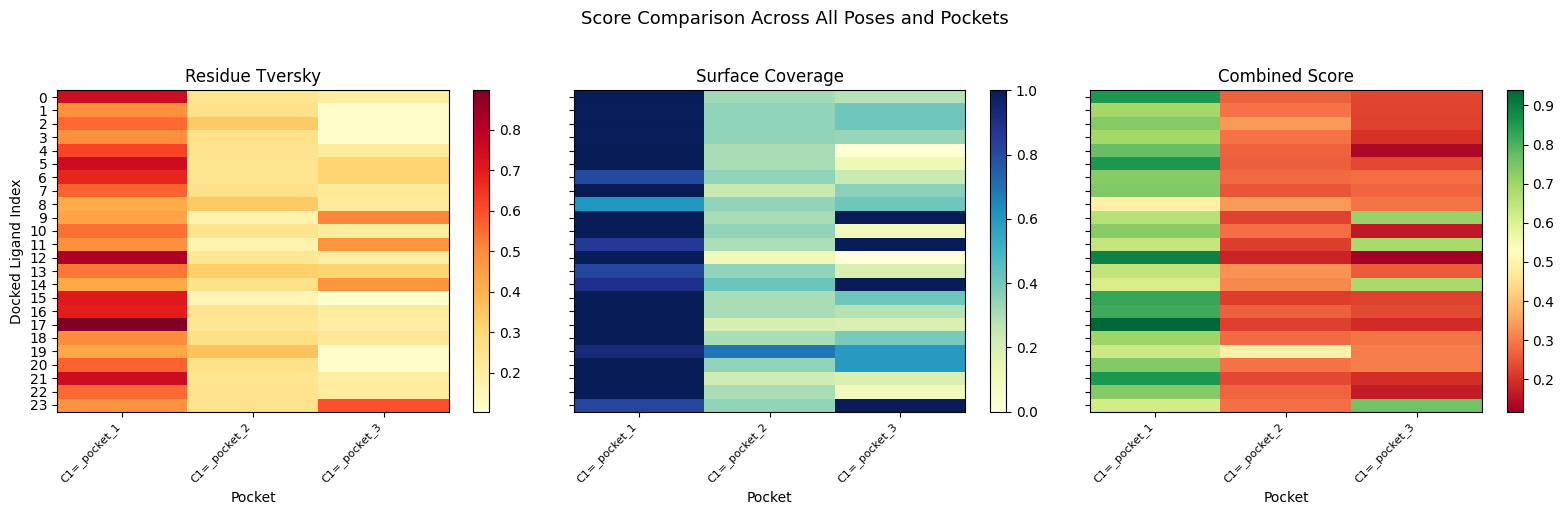

In [ ]:
best_wf = select_best_pose(wf_combined_df, rank_by="combined_score", aggregation="sum")
best_wm = select_best_pose(wm_combined_df, rank_by="combined_score", aggregation="sum")

print(f"WaterFLAP → best pose: {best_wf['docked_ligand_index'].iloc[0]}  "
      f"(aggregated = {best_wf['aggregated_score'].iloc[0]:.4f})")
print(f"WaterMap  → best pose: {best_wm['docked_ligand_index'].iloc[0]}  "
      f"(aggregated = {best_wm['aggregated_score'].iloc[0]:.4f})")

if best_wf["docked_ligand_index"].iloc[0] == best_wm["docked_ligand_index"].iloc[0]:
    print("\n✓ Both water methods agree on the best pose.")
else:
    print("\n✗ Different best poses — water method matters for this system.")

### Score component heatmaps — WaterFLAP combined

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

cols = ["residue_tversky", "surface_coverage", "water_displaced_count", "combined_score"]
titles = ["Residue Tversky", "Surface Coverage", "Waters Displaced (WF)", "Combined Score (WF)"]
cmaps = ["YlOrRd", "YlGnBu", "Reds", "RdYlGn"]

for ax, col, title, cmap in zip(axes, cols, titles, cmaps):
    pivot = wf_combined_df.pivot(
        index="docked_ligand_index", columns="pocket_name", values=col
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    ax.set_xlabel("Pocket")
    fig.colorbar(im, ax=ax)

axes[0].set_ylabel("Docked Ligand Index")
plt.suptitle("WaterFLAP — Score Components", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Score component heatmaps — WaterMap combined

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

cols = ["residue_tversky", "surface_coverage", "water_displaced_count", "combined_score"]
titles = ["Residue Tversky", "Surface Coverage", "Waters Displaced (WM)", "Combined Score (WM)"]
cmaps = ["YlOrRd", "YlGnBu", "Blues", "RdYlGn"]

for ax, col, title, cmap in zip(axes, cols, titles, cmaps):
    pivot = wm_combined_df.pivot(
        index="docked_ligand_index", columns="pocket_name", values=col
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    ax.set_xlabel("Pocket")
    fig.colorbar(im, ax=ax)

axes[0].set_ylabel("Docked Ligand Index")
plt.suptitle("WaterMap — Score Components", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Pocket annotation

Add a `pocket_name` column to every interaction row — shows which pocket each residue contact belongs to (or `None` if outside all pockets).

In [25]:
annotated = annotate_all_pockets(interactions_df, residue_scorers)

print(f"Original rows: {len(interactions_df)}")
print(f"Annotated rows: {len(annotated)} (expanded for multi-pocket residues)")
print(f"Pocket assignments: {annotated['pocket_name'].value_counts(dropna=False).to_dict()}")
annotated.head(10)

Original rows: 1531
Annotated rows: 1717 (expanded for multi-pocket residues)
Pocket assignments: {'C1=_pocket_1': 1083, 'C1=_pocket_2': 354, 'C1=_pocket_3': 255, None: 25}


,docked_ligand_index,interaction_type,ligand_atom_indices,ligand_atom_types,residue_name,residue_number,residue_atom_indices,residue_atom_types,residue_atom_bb_sc,interaction_distance,functional_groups,pocket_name
0,0,Hydrophobic,"(13,)","('C',)",PHE,313,"(3713,)","('C',)","('sc',)",3.990,"('No_fg',)",C1=_pocket_1
1,0,Hydrophobic,"(15,)","('C',)",PHE,313,"(3711,)","('C',)","('sc',)",4.084,"('No_fg',)",C1=_pocket_1
2,0,Hydrophobic,"(15,)","('C',)",PHE,313,"(3713,)","('C',)","('sc',)",3.768,"('No_fg',)",C1=_pocket_1
3,0,Hydrophobic,"(16,)","('C',)",PHE,313,"(3711,)","('C',)","('sc',)",3.928,"('No_fg',)",C1=_pocket_1
4,0,Hydrophobic,"(16,)","('C',)",PHE,313,"(3713,)","('C',)","('sc',)",4.100,"('No_fg',)",C1=_pocket_1
5,0,VdWContact,"(37,)","('H',)",SER,124,"(1363,)","('C',)","('sc',)",2.682,"('No_fg',)",C1=_pocket_1
6,0,VdWContact,"(37,)","('H',)",SER,124,"(1367,)","('H',)","('sc',)",2.126,"('No_fg',)",C1=_pocket_1
7,0,Hydrophobic,"(19,)","('C',)",PHE,341,"(3963,)","('C',)","('sc',)",3.845,"('No_fg',)",C1=_pocket_3
8,0,Hydrophobic,"(20,)","('C',)",PHE,341,"(3961,)","('C',)","('sc',)",3.835,"('No_fg',)",C1=_pocket_3
9,0,Hydrophobic,"(20,)","('C',)",PHE,341,"(3963,)","('C',)","('sc',)",3.480,"('No_fg',)",C1=_pocket_3


### Filter: interactions for the best pose that fall inside a pocket

In [ ]:
best_idx = best_wf["docked_ligand_index"].iloc[0]
best_annotated = annotated[
    (annotated["docked_ligand_index"] == best_idx)
    & (annotated["pocket_name"].notna())
]

print(f"Best pose {best_idx} (WaterFLAP): {len(best_annotated)} in-pocket interactions\n")
print("Pocket breakdown:")
print(best_annotated.groupby("pocket_name")["interaction_type"].value_counts().to_string())

Best pose 23: 93 in-pocket interactions

Pocket breakdown:
pocket_name   interaction_type
C1=_pocket_1  Hydrophobic         27
              VdWContact          18
              PiStacking           1
C1=_pocket_2  VdWContact          16
              Hydrophobic          2
C1=_pocket_3  Hydrophobic         15
              VdWContact          14


## 7. Aggregation comparison

Compare different aggregation strategies (`sum`, `mean`, `max`) to see if they select the same best pose.

In [ ]:
print("WaterFLAP combined:")
for agg in ["sum", "mean", "max"]:
    b = select_best_pose(wf_combined_df, rank_by="combined_score", aggregation=agg)
    idx = b["docked_ligand_index"].iloc[0]
    agg_score = b["aggregated_score"].iloc[0]
    print(f"  aggregation={agg:4s} → best pose = {idx}, aggregated_score = {agg_score:.4f}")

print("\nWaterMap combined:")
for agg in ["sum", "mean", "max"]:
    b = select_best_pose(wm_combined_df, rank_by="combined_score", aggregation=agg)
    idx = b["docked_ligand_index"].iloc[0]
    agg_score = b["aggregated_score"].iloc[0]
    print(f"  aggregation={agg:4s} → best pose = {idx}, aggregated_score = {agg_score:.4f}")

  aggregation=sum  → best pose = 23, aggregated_score = 1.6626
  aggregation=mean → best pose = 23, aggregated_score = 0.5542
  aggregation=max  → best pose = 17, aggregated_score = 0.9385


## 8. 3D visualisation of top poses

Display the top-ranked docked poses in the pocket using `py3Dmol`. The best pose (by aggregated combined score) is shown in green; runner-up poses are shown in cyan.

In [28]:
import py3Dmol

# Select top N poses by aggregated combined score
TOP_N = 5
agg_scores = (
    wf_combined_df.groupby("docked_ligand_index")["combined_score"]
    .sum()
    .sort_values(ascending=False)
)
top_indices = agg_scores.head(TOP_N).index.tolist()
print(f"Top {TOP_N} poses (by aggregated combined score): {top_indices}")

# Build py3Dmol viewer
viewer = py3Dmol.view(width=800, height=500)

# Add protein structure
protein_pdb = DATA_DIR / "8IRV.pdb"
with open(protein_pdb) as f:
    protein_block = f.read()
viewer.addModel(protein_block, "pdb")
viewer.getModel(-1).setStyle({}, {"cartoon": {"color": "lightgray", "opacity": 0.7}})

# Collect pocket residue numbers for highlighting
pocket_residue_nums = set()
for scorer in residue_scorers.values():
    pocket_residue_nums.update(scorer.pocket_residues)

# Highlight pocket residues as lines
viewer.getModel(0).setStyle(
    {"resi": list(pocket_residue_nums)},
    {
        "cartoon": {"color": "lightgray", "opacity": 0.7},
        "line": {"color": "salmon", "opacity": 0.6},
    },
)

# Add reference ligand (crystal pose)
ref_sdf = DATA_DIR / "8IRV_R5F_lig.sdf"
ref_supplier = Chem.SDMolSupplier(str(ref_sdf), removeHs=False)
ref_mol = next(m for m in ref_supplier if m is not None)
ref_block = Chem.MolToMolBlock(ref_mol)
viewer.addModel(ref_block, "sdf")
viewer.getModel(-1).setStyle({}, {"stick": {"colorscheme": "orangeCarbon", "radius": 0.18}})

# Add each top pose from the SDF
for rank, pose_idx in enumerate(top_indices):
    mol = mols[pose_idx]
    mol_block = Chem.MolToMolBlock(mol)
    color = "greenCarbon" if rank == 0 else "cyanCarbon"
    viewer.addModel(mol_block, "sdf")
    model = viewer.getModel(-1)
    if rank == 0:
        model.setStyle({}, {"stick": {"colorscheme": color, "radius": 0.15}})
    else:
        model.setStyle({}, {"stick": {"colorscheme": color, "radius": 0.1, "opacity": 0.7}})

# Add pocket surface vertices as small spheres for context
npz_data = np.load(npz_path)
for pocket_name in pocket_names:
    verts = npz_data[pocket_name]
    xyz_str = "\n".join(
        f"HETATM{i+1:5d}  X   SRF A   1    {x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           X"
        for i, (x, y, z) in enumerate(verts)
    )
    pdb_block = f"REMARK pocket {pocket_name}\n{xyz_str}\nEND\n"
    viewer.addModel(pdb_block, "pdb")
    viewer.getModel(-1).setStyle({}, {"sphere": {"radius": 0.4, "color": "gray", "opacity": 0.25}})

viewer.zoomTo({"model": 1})
viewer.zoom(0.7)
viewer.show()

Top 5 poses (by aggregated combined score): [23, 19, 0, 20, 18]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.